# Mean-Variance Portfolio Optimization with cuOpt

<div style="background-color: #e3f2fd; border-left: 6px solid #1976d2; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">📘 Optional Notebook</h4>
We now support solving <strong>Quadratic Programs (QP)</strong>, enabling standard <strong>Markowitz Mean-Variance</strong> portfolio optimization directly on the GPU.

This notebook shows how the same framework extends to QP problems with a quadratic objective with variance as the risk measure <code>w'Σw</code>.
</div>


## Table of Contents

1. [Setup](#setup) — GPU check & imports
2. [Mathematical Formulation](#introduction) — The Markowitz QP
3. [Solve with cuOpt](#solve) — Data, parameters & GPU optimization
4. [Results](#analyze) — Portfolio visualization & statistics
5. [CPU Solver Comparison](#cpu-comparison) — Clarabel vs cuOpt


---

<a id='setup'></a>
## 1. Setup


In [1]:
!nvidia-smi

Thu Sep  3 11:30:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.43.02              KMD Version: 610.43.02     CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 5000 Blac...    Off |   00000000:02:00.0 Off |                  Off |
| N/A   40C    P8              8W /   55W |     285MiB /  24463MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os

import cvxpy as cp
import numpy as np

from portfolio_optimization import mean_variance_optimizer, utils
from portfolio_optimization.mean_variance_parameters import MeanVarianceParameters
from portfolio_optimization.settings import ApiSettings, ReturnsComputeSettings
from portfolio_optimization import portfolio_components

---

<a id='introduction'></a>
## 2. Mathematical Formulation

<div style="background-color: #f3e5f5; border-left: 6px solid #9c27b0; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">💡 Mean-Variance (Markowitz) Optimization</h4>
Mean-Variance optimization, introduced by Harry Markowitz in 1952, is the foundation of Modern Portfolio Theory. The objective trades off expected return against portfolio variance:

\begin{align*}
\text{maximize } \quad &\mu^\top w - \lambda_{\text{risk}} \cdot w^\top \Sigma w\\
\text{subject to} \quad 
& \sum_i w_i + c = 1 \quad \text{(self-financing)}\\
& w_i^{\text{min}} \leq w_i \leq w_i^{\text{max}}, \forall i \quad \text{(concentration)}\\
& c^{\text{min}} \leq c \leq c^{\text{max}} \quad \text{(cash)}\\
& L = \|w\|_1 \leq L^{\text{limit}} \quad \text{(leverage)}\\
& T = \|w - w_{\text{prev}}\|_1 \leq T^{\text{limit}} \quad \text{(turnover)}
\end{align*}

This is a **Quadratic Program (QP)** due to the $w^\top \Sigma w$ term. cuOpt 26.02 introduces QP support via a GPU-accelerated barrier solver.
</div>


---

<a id='solve'></a>
## 3. Solve with cuOpt

<div style="background-color: #e8f5e9; border-left: 6px solid #388e3c; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">🚀 End-to-End: Data → Parameters → GPU Solve</h4>
We load S&P 500 price data, compute log-returns, define portfolio constraints, and solve the QP on the GPU using cuOpt.
</div>

<div style="background-color: #fff8e1; border-left: 6px solid #f9a825; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">⚠️ Disclaimer</h4>
Each user is responsible for checking the content of datasets and the applicable licenses and determining if suitable for the intended use.
</div>


In [3]:
dataset_name = "sp500"
data_path = f"../data/stock_data/{dataset_name}.csv"

if not os.path.exists(data_path):
    utils.download_data(data_path)

returns_dict = utils.calculate_returns(
    data_path,
    {"name": "recent", "range": ("2022-01-01", "2024-01-01")},
    ReturnsComputeSettings(return_type="LOG", freq=1),
)

print(
    f"Assets: {len(returns_dict['tickers'])}  |  "
    f"Observations: {len(returns_dict['returns'])}  |  "
    f"Covariance: {returns_dict['covariance'].shape}"
)

Assets: 384  |  Observations: 500  |  Covariance: (384, 384)


In [4]:
#Set c_max so that the portfolio components display knows how much cash was used to remove leaving just the securities
c_max=0.2
mean_variance_params = MeanVarianceParameters(
    w_min={"NVDA": 0.1, "others": -0.3},
    w_max={"NVDA": 0.6, "others": 0.4},
    c_min=0.0,
    c_max=c_max,
    L_tar=1.6,
    risk_aversion=1.0,
)

### Solve with CVXPY API

In [5]:
mean_variance_problem = mean_variance_optimizer.MeanVariance(
    returns_dict=returns_dict,
    mean_variance_params=mean_variance_params,
    api_settings=ApiSettings(api="cvxpy"),
)

cvxpy_gpu_results, cvxpy_gpu_portfolio = (
    mean_variance_problem.solve_optimization_problem(
        solver_settings={"solver": cp.CUOPT, "time_limit": 60, "verbose": True}
    )
)

(CVXPY) Sep 03 11:30:12 AM: Your problem has 385 variables, 2 constraints, and 2 parameters.
(CVXPY) Sep 03 11:30:12 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Sep 03 11:30:12 AM: DCP verification time: 0.0003 seconds.
(CVXPY) Sep 03 11:30:12 AM: Expression tree has 8 nodes.
(CVXPY) Sep 03 11:30:12 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Sep 03 11:30:12 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Sep 03 11:30:12 AM: Compiling problem (target solver=CUOPT).
(CVXPY) Sep 03 11:30:12 AM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> EliminateZeroSized -> ConeMatrixStuffing -> CUOPT
(CVXPY) Sep 03 11:30:12 AM: Applying reduction Dcp2Cone
(CVXPY) Sep 03 11:30:12 AM: Applying reduction CvxAttr2Constr
(CVXPY) Sep 03 11:30:12 AM: Applying reduction EliminateZeroSized
(CVXPY) Sep 03 11:30:12 AM: Applying reduction ConeMatrixStuffing
(CVXPY) Sep 03 11:30:12 AM: Applyin

                                     CVXPY                                     
                                     v1.9.2                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
Setting parameter log_to_console to true
Setting parameter time_limit to 6.000000e+01
cuOpt version: 26.4.0, git hash: d9b7c96a, host arch: x86_64, device archs: 75-real,80-real,86-real,90a-real,100f-real,120a-real,120
CPU: Intel(R) Core(TM) Ultra 9 285HX, threads (physical/logical): 24/24, RAM: 89.25 GiB
CUDA 13.0, device: NVIDIA RTX PRO 5000 Blackwell Gene

(CVXPY) Sep 03 11:30:13 AM: Problem status: optimal
(CVXPY) Sep 03 11:30:13 AM: Optimal value: -2.892e-03
(CVXPY) Sep 03 11:30:13 AM: Compilation took 5.815e-02 seconds
(CVXPY) Sep 03 11:30:13 AM: Solver (including time spent in interface) took 6.667e-01 seconds




                  Objective                         Infeasibility        Time
Iter   Primal              Dual                Primal   Dual    Compl.   Elapsed
  0   +6.221705684600e+08 -6.221915970518e+08 5.94e+04 3.87e+02 3.43e-04 0.3
  1   +5.959371435839e+08 -5.959580349412e+08 5.81e+04 3.78e+02 3.50e-04 0.3
  2   +5.907151295561e+08 -5.907359853813e+08 5.78e+04 3.76e+02 3.52e-04 0.3
  3   +5.469210788718e+08 -5.469415725836e+08 5.57e+04 3.63e+02 4.35e-04 0.3
  4   +4.602730818607e+08 -4.602927638874e+08 5.11e+04 3.33e+02 6.69e-04 0.3
  5   +2.517837005560e+08 -2.518005575129e+08 3.78e+04 2.46e+02 1.92e-03 0.4
  6   +7.883344947721e+06 -7.891448807048e+06 6.69e+03 4.36e+01 5.32e-02 0.4
  7   +7.925536960329e+04 -8.532608526229e+04 6.71e+02 4.37e+00 5.96e-01 0.4
  8   +8.360385008576e+02 -6.004901783678e+03 6.89e+01 4.49e-01 5.85e+00 0.4
  9   +1.413276783228e+01 -2.766539278770e+03 8.96e+00 5.83e-02 4.36e+01 0.4
 10   +7.623485331318e-01 -1.618024188703e+03 2.08e+00 1.35e-02 9.93e

### Solve using cuOpt Python API

In [6]:
mean_variance_problem = mean_variance_optimizer.MeanVariance(
    returns_dict=returns_dict,
    mean_variance_params=mean_variance_params,
    api_settings=ApiSettings(api="cuopt_python"),
)

gpu_results, gpu_portfolio = mean_variance_problem.solve_optimization_problem(
    solver_settings={"time_limit": 60, "log_to_console": True}
)

cuOpt MEAN-VARIANCE PROBLEM SETUP COMPLETED
Variables: 384 weights + 1 cash + 768 leverage aux
Covariance matrix: 384x384
Linear terms: 384
Problem Type: QP (Quadratic Programming)
Setting parameter time_limit to 6.000000e+01
Setting parameter log_to_console to true
cuOpt version: 26.4.0, git hash: d9b7c96a, host arch: x86_64, device archs: 75-real,80-real,86-real,90a-real,100f-real,120a-real,120
CPU: Intel(R) Core(TM) Ultra 9 285HX, threads (physical/logical): 24/24, RAM: 88.83 GiB
CUDA 13.0, device: NVIDIA RTX PRO 5000 Blackwell Generation Laptop GPU (ID 0), VRAM: 23.46 GiB
CUDA device UUID: 1f32ffffffb119-7effffff87-ffffffec0e

Problem has a quadratic objective. Using Barrier.
Solving a problem with 386 constraints, 1153 variables (0 integers), and 2305 nonzeros
Problem scaling:
Objective coefficents range:          [1e-06, 3e-03]
Constraint matrix coefficients range: [1e+00, 1e+00]
Constraint rhs / bounds range:        [0e+00, 2e+00]
Variable bounds range:                [1e-01, 6e

---

<a id='analyze'></a>
## 4. Results


<div style="background-color: #fff8e1; border-left: 6px solid #f9a825; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">📏 Units — every statistic here is daily</h4>
Returns were computed as <strong>1-day log returns</strong> (<code>ReturnsComputeSettings(return_type="LOG", freq=1)</code>), so the expected return, volatility, and variance in the solver printouts above and the statistics below are <strong>daily</strong> quantities, not annualized. Daily log returns annualize additively: a daily expected log return of 0.29% is about a 73% annualized <em>log</em> return, i.e. <code>e^0.73 − 1 ≈ 108%</code> annualized <em>simple</em> return. These are in-sample historical means over the selected regime window — an artifact of the optimizer selecting the sample's best performers, not a return forecast.
</div>


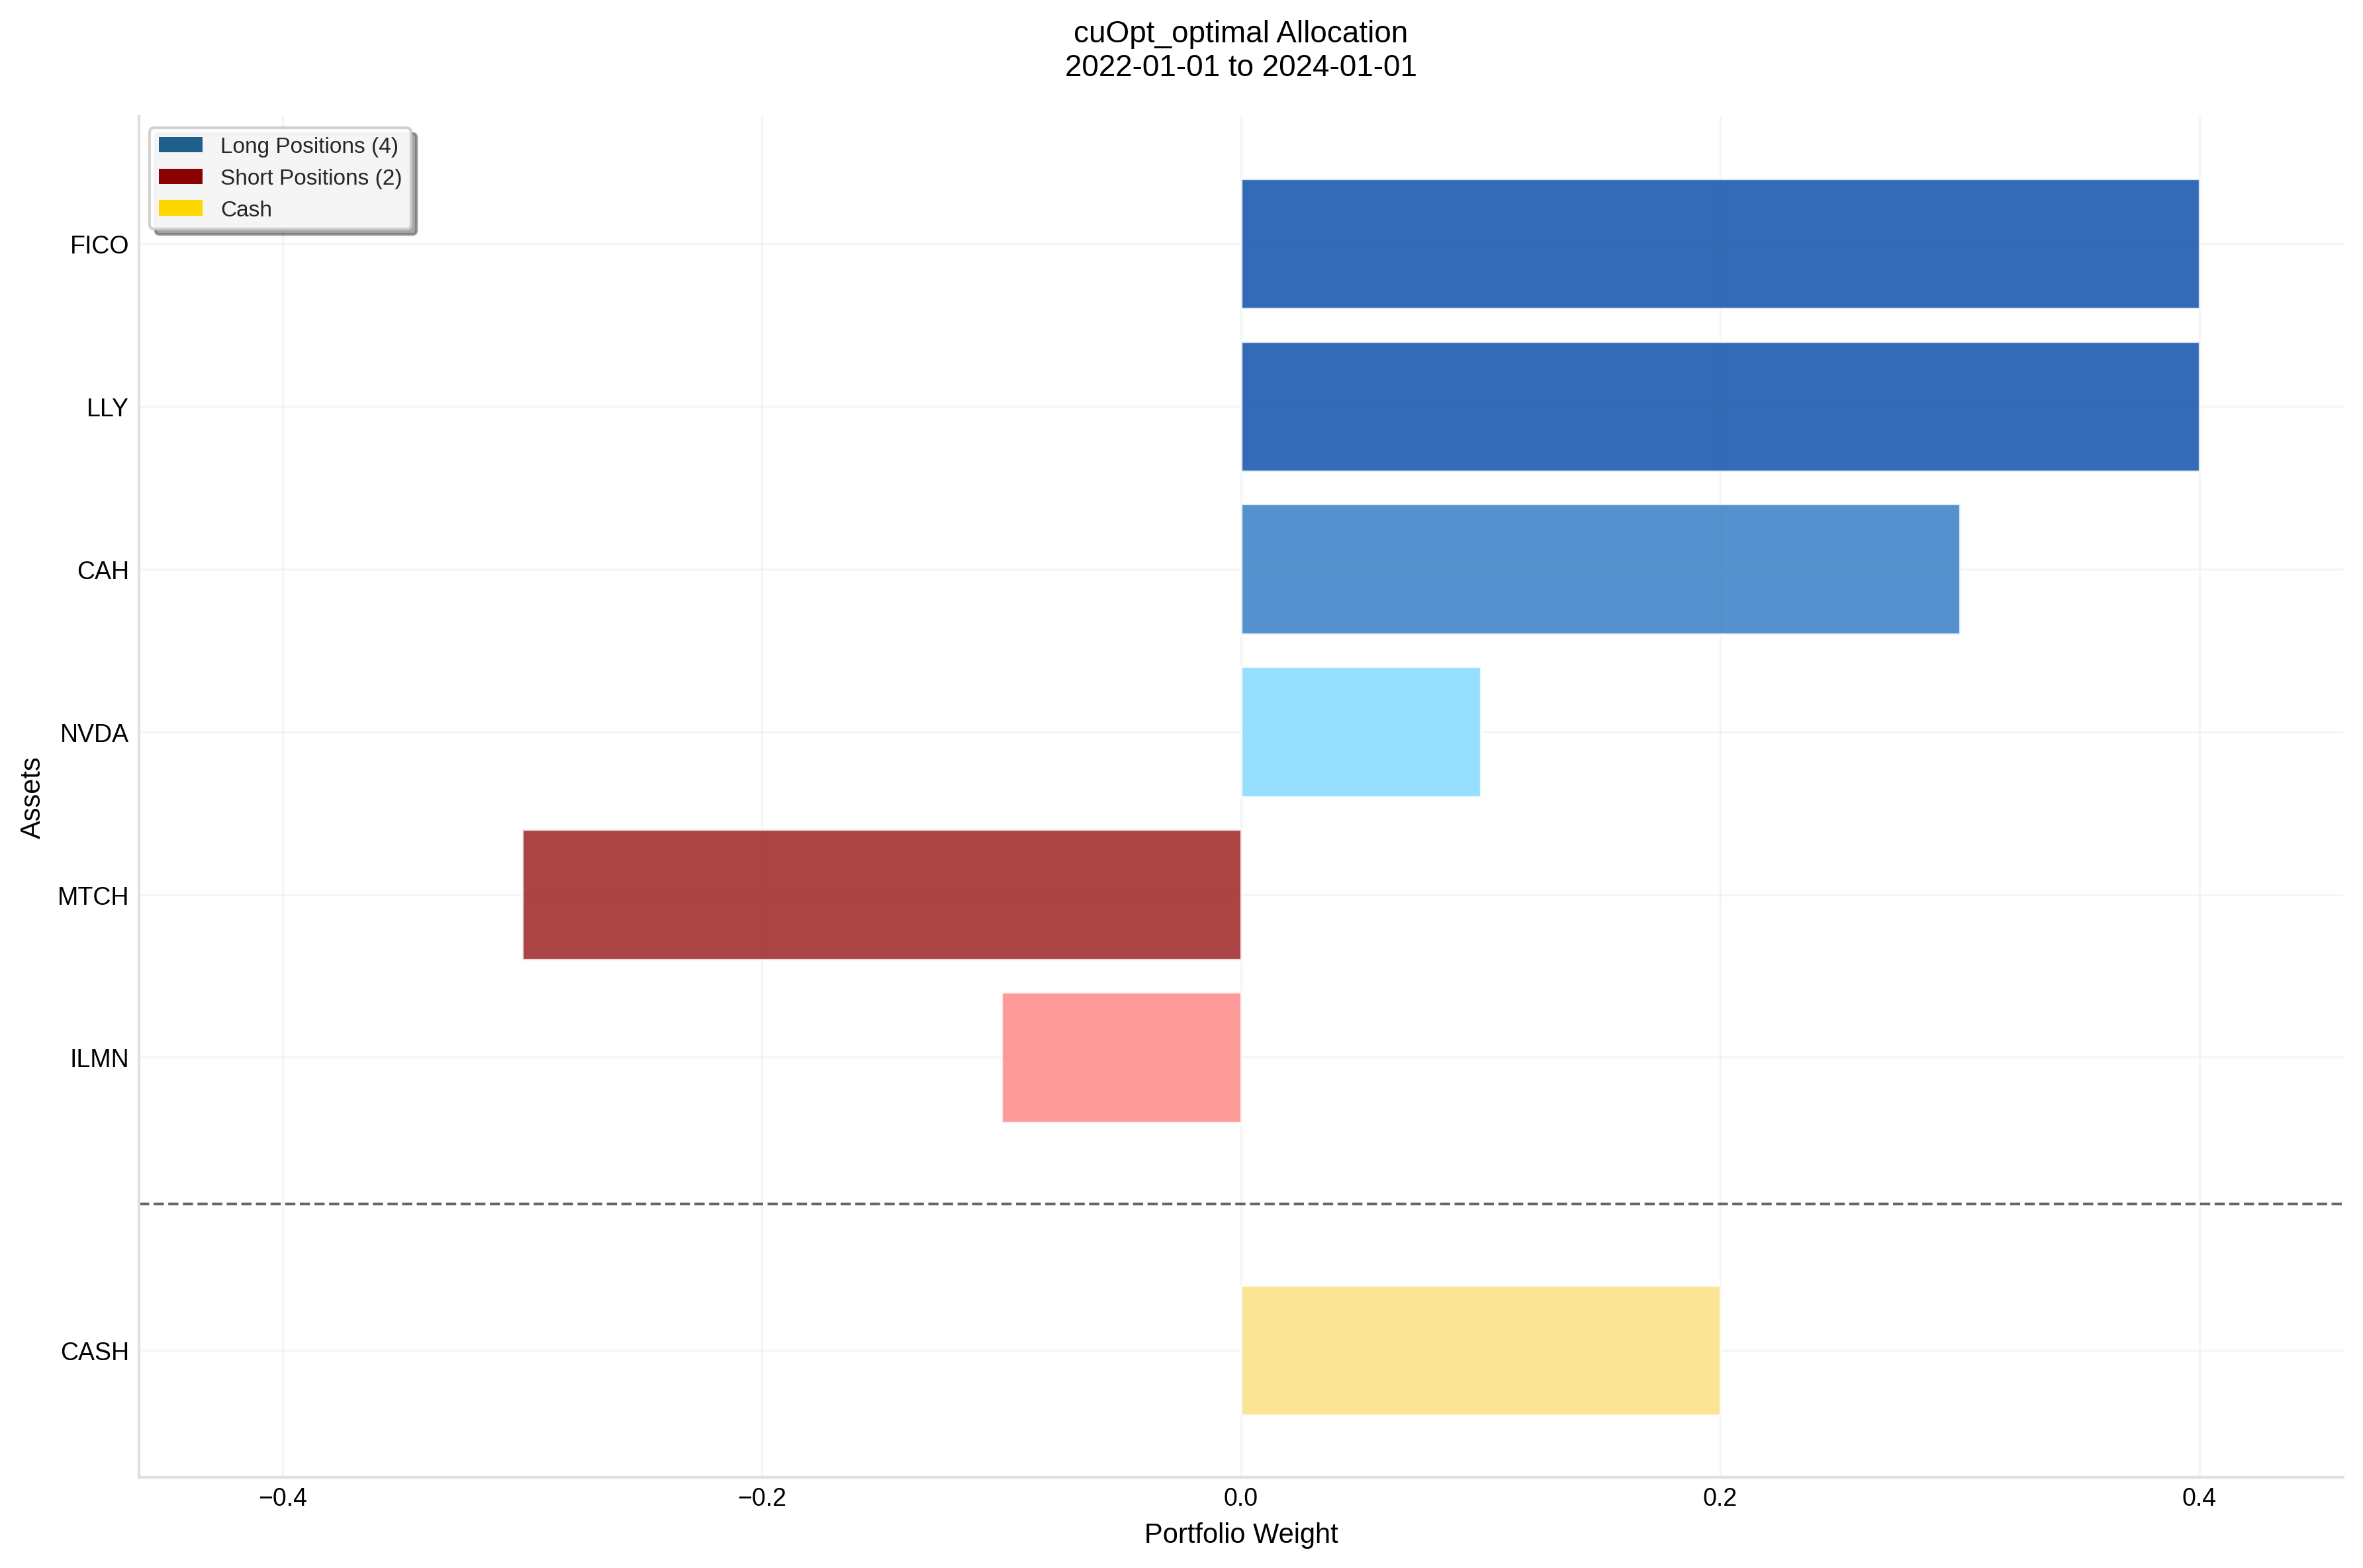

In [7]:
ax = gpu_portfolio.plot_portfolio(show_plot=True, min_percentage=1)

In [8]:
#Find vector length for in-sample periods in trading days
import pandas_market_calendars as mcal
nyse = mcal.get_calendar('NYSE')
# Find valid trading days between the dates
valid_days = nyse.valid_days(
    start_date=gpu_portfolio.time_range[0], end_date=gpu_portfolio.time_range[1]
)
length = len(valid_days)
print(length)

501


In [9]:
#Extract tickers and weights and adjust weights to ignore the cash position as it does not change with stock market
tickers, weights = gpu_portfolio.tickers, gpu_portfolio.weights
filtered = [(t, w) for t, w in zip(gpu_portfolio.tickers, gpu_portfolio.weights) if w.round(3) != 0.000]
#Unpack arrays:
tickers, weights = map(list, zip(*filtered)) if filtered else ([], [])
sum(weights)

np.float64(0.7999971869044773)

In [10]:
#Extract tickers and weights and adjust weights to ignore the cash position as it does not change with stock market
if c_max > 0.0:
    weights = [weights[i]/(1-c_max) for i in range(len(weights))]
[round(x, 5) for x in weights],sum(weights)

([np.float64(0.375),
  np.float64(0.5),
  np.float64(-0.125),
  np.float64(0.5),
  np.float64(-0.375),
  np.float64(0.125)],
 np.float64(0.9999964836305966))

['CAH', 'FICO', 'ILMN', 'LLY', 'MTCH', 'NVDA'] [np.float64(0.375), np.float64(0.5), np.float64(-0.125), np.float64(0.5), np.float64(-0.375), np.float64(0.125)]
0.9999956768591768
(501,) (501,)


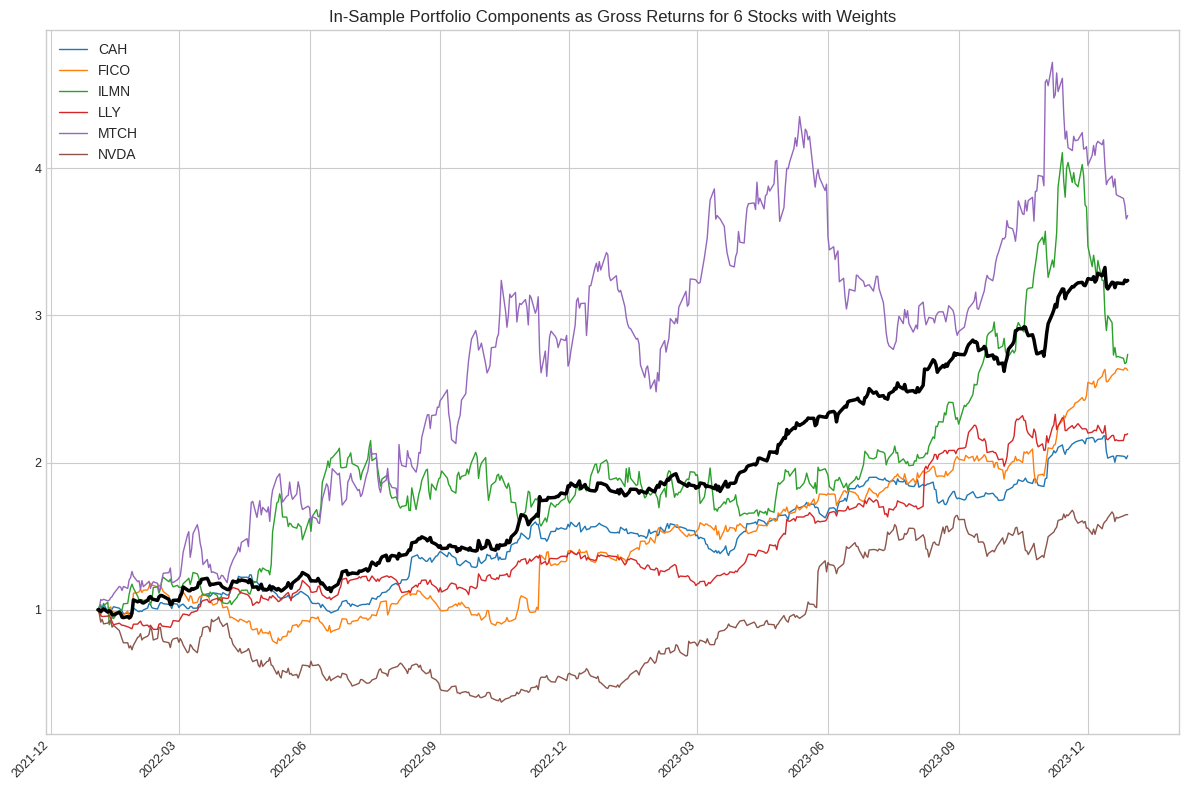

In [11]:
#Display the portfolio components:
print(tickers,[round(x, 5) for x in weights])
print(sum(weights))
start = returns_dict['regime']['range'][0]
end   = returns_dict['regime']['range'][1]
from portfolio_optimization import portfolio_components
portv = portfolio_components.displayComponents(tickers,weights,length=length,start=start,end=end,isShowPortv=True)

In [10]:
weights = gpu_portfolio.weights

expected_return = np.dot(returns_dict["mean"], weights)
portfolio_variance = weights @ returns_dict["covariance"] @ weights
portfolio_std = np.sqrt(portfolio_variance)
sharpe_ratio = expected_return / portfolio_std if portfolio_std > 0 else 0

# Inputs are 1-day LOG returns, so the statistics above are all DAILY figures.
# Log returns annualize additively (x252); volatility scales with sqrt(252).
TRADING_DAYS = 252
annual_log_return = expected_return * TRADING_DAYS
annual_simple_return = np.exp(annual_log_return) - 1
annual_volatility = portfolio_std * np.sqrt(TRADING_DAYS)
annual_sharpe = sharpe_ratio * np.sqrt(TRADING_DAYS)

cash = float(np.asarray(gpu_portfolio.cash).squeeze())

print("Portfolio Statistics (daily, from 1-day log returns):")
print(f"  Expected Return:  {expected_return:.4%} per day")
print(f"  Volatility (Std): {portfolio_std:.4%} per day")
print(f"  Variance:         {portfolio_variance:.6f}")
print(f"  Sharpe Ratio:     {sharpe_ratio:.4f}")
print(f"  Cash Allocation:  {cash:.2%}")
print(f"  Leverage:         {np.sum(np.abs(weights)):.4f}")
print(f"  Number of positions: {np.sum(np.abs(weights) > 0.001)}")
print()
print("Annualized (252 trading days, in-sample):")
print(f"  Log Return:    {annual_log_return:.2%}")
print(f"  Simple Return: {annual_simple_return:.2%}")
print(f"  Volatility:    {annual_volatility:.2%}")
print(f"  Sharpe Ratio:  {annual_sharpe:.2f}")

Portfolio Statistics (daily, from 1-day log returns):
  Expected Return:  0.2914% per day
  Volatility (Std): 1.5327% per day
  Variance:         0.000235
  Sharpe Ratio:     0.1901
  Cash Allocation:  20.00%
  Leverage:         1.6000
  Number of positions: 6

Annualized (252 trading days, in-sample):
  Log Return:    73.43%
  Simple Return: 108.40%
  Volatility:    24.33%
  Sharpe Ratio:  3.02


---

<a id='cpu-comparison'></a>
## 5. CPU Solver Comparison

<div style="background-color: #fff3e0; border-left: 6px solid #f57c00; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">🔄 GPU vs CPU</h4>
Solve the same Mean-Variance problem using <strong>Clarabel</strong> (a CPU-based interior-point solver) and compare the results against the GPU solution above. For small portfolios the GPU advantage in solve time alone may be modest, but running the entire pipeline on GPU — data preprocessing, returns forecasting, scenario generation, and optimization — eliminates costly CPU↔GPU data transfers and delivers end-to-end speedups that grow with problem size.
</div>

<div style="background-color: #fff8e1; border-left: 6px solid #f9a825; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">⏱️ Timing methodology — cold-start solves</h4>
All committed solve times come from a single top-to-bottom execution on a cold kernel, so each solver pays its full one-time cost (CVXPY canonicalization, library initialization). Re-solving the same problem object in a warm session is roughly 40% faster for the CPU solver because CVXPY reuses its cached canonicalization — so interactive re-runs of this cell will report faster CPU times than a fresh end-to-end execution. Cold-start numbers are what a first-time reader reproduces.
</div>

In [12]:
cpu_problem = mean_variance_optimizer.MeanVariance(
    returns_dict=returns_dict,
    mean_variance_params=mean_variance_params,
    api_settings=ApiSettings(api="cvxpy"),
)

cpu_results, cpu_portfolio = cpu_problem.solve_optimization_problem(
    solver_settings={"solver": cp.CLARABEL}
)


MEAN-VARIANCE OPTIMIZATION RESULTS
PROBLEM CONFIGURATION
------------------------------
Solver:              CLARABEL
Regime:              recent
Time Period:         2022-01-01 to 2024-01-01
Assets:              384

PERFORMANCE METRICS
------------------------------
Expected Return:     0.002914 (0.2914%)
Variance:            0.000235
Std Deviation:       0.015327
Objective Value:     -0.002892

SOLVING PERFORMANCE
------------------------------
Setup Time:          0.6717 seconds
CVXPY API Overhead:  0.0073 seconds
Solve Time:          0.1006 seconds

OPTIMAL PORTFOLIO ALLOCATION
------------------------------

PORTFOLIO: CLARABEL_OPTIMAL
----------------------------------------
Period: 2022-01-01 to 2024-01-01

LONG POSITIONS (4 assets)
-------------------------
FICO        0.400 ( 40.00%)
LLY         0.400 ( 40.00%)
CAH         0.300 ( 30.00%)
NVDA        0.100 ( 10.00%)
Total Long    1.200 (120.00%)

SHORT POSITIONS (2 assets)
--------------------------
MTCH       -0.300 (-30.00

In [13]:
utils.compare_results(gpu_results.to_dict(), cpu_results.to_dict())


SOLVER COMPARISON
Solver          solve time   obj          return       variance    
----------------------------------------------------------------------
cuOpt (GPU)     0.180610     -0.002892    0.002914     0.000235    
CLARABEL (CPU)  0.100620     -0.002892    0.002914     0.000235    

Objective Differences:
  cuOpt (GPU) vs CLARABEL (CPU): 0.00000001



### Compare portfolio composition

`compare_results` above compares solve metrics (solver, time, objective, return, variance). To compare the **holdings**, line the weight vectors up side by side. Because the problem is convex with a single optimum, every solver should agree to solver tolerance (roughly `1e-4` per weight); return and objective agree far tighter.


In [14]:
import pandas as pd

composition = pd.DataFrame(
    {
        "cuOpt (direct)": np.asarray(gpu_portfolio.weights, dtype=float),
        "cuOpt (via CVXPY)": np.asarray(cvxpy_gpu_portfolio.weights, dtype=float),
        "CLARABEL (CPU)": np.asarray(cpu_portfolio.weights, dtype=float),
    },
    index=returns_dict["tickers"],
)
composition["GPU-CPU diff"] = (
    composition["cuOpt (direct)"] - composition["CLARABEL (CPU)"]
)

top_positions = composition.reindex(
    composition["cuOpt (direct)"].abs().sort_values(ascending=False).index
).head(10)
display(top_positions.round(6))

gpu_cash = float(np.asarray(gpu_portfolio.cash).squeeze())
cpu_cash = float(np.asarray(cpu_portfolio.cash).squeeze())
print(f"max |GPU-CPU| weight difference: {composition['GPU-CPU diff'].abs().max():.2e}")
print(f"L1 weight difference:            {composition['GPU-CPU diff'].abs().sum():.2e}")
print(f"cash — cuOpt: {gpu_cash:.4f} | CLARABEL: {cpu_cash:.4f}")

,cuOpt (direct),cuOpt (via CVXPY),CLARABEL (CPU),GPU-CPU diff
FICO,0.400000,0.399999,0.4,-0.000000
LLY,0.399998,0.399998,0.4,-0.000002
MTCH,-0.299999,-0.299999,-0.3,0.000001
CAH,0.299996,0.299997,0.3,-0.000004
NVDA,0.100000,0.100000,0.1,0.000000
ILMN,-0.099998,-0.099998,-0.1,0.000002
STLD,0.000000,0.000000,0.0,0.000000
OXY,0.000000,0.000000,0.0,0.000000
PWR,0.000000,0.000000,0.0,0.000000
PHM,0.000000,0.000000,0.0,0.000000


max |GPU-CPU| weight difference: 3.62e-06
L1 weight difference:            1.29e-05
cash — cuOpt: 0.2000 | CLARABEL: 0.2000


---

## Summary

<div style="background-color: #e8f5e9; border-left: 6px solid #388e3c; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">✅ Key Takeaway</h4>
<strong>cuOpt >= 26.02</strong> adds QP support, enabling GPU-accelerated Markowitz Mean-Variance optimization alongside the existing LP-based CVaR solver. This portfolio optimization example handles both problem types — simply choose the appropriate optimizer class.

### Mean-Variance vs CVaR

| Aspect | Mean-Variance | CVaR |
|--------|---------------|------|
| Risk Measure | Variance (symmetric) | Tail risk (asymmetric) |
| Problem Type | QP (Quadratic) | LP (Linear) |
| Data Needed | Mean + Covariance | Scenarios |
| Distribution | Assumes normal | Distribution-free |

</div>
